In [1]:
# source venv/bin/activate  

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata

ImportError: cannot import name 'Cmip6MeteorDataGetter' from 'meteor' (/Users/nste/anaconda3/envs/meteor/lib/python3.9/site-packages/meteor-0+untagged.168.gea93127-py3.9.egg/meteor/__init__.py)

In [2]:
## NBVAL_IGNORE_OUTPUT
#sys.path.insert(0,os.path.join(os.getcwd(), '../'))
#module_path = os.path.abspath(os.path.join('../src'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

#cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

In [2]:
savecache=1
#loadcache=1

cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

Getting CMIP6 data from the zarrstore for tas

In [3]:
flds = ["tas","pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], flds = flds, dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])

In [5]:
#for property, value in vars(data_getter).items():
#    print(property)

In [30]:
models = data_getter.models
if 'MCM-UA-1-0' in models: models.pop(models.index('MCM-UA-1-0'))  # drop because of some data issue
#if 'MIROC-ES2L' in models: models.pop(models.index('MIROC-ES2L'))  # drop because of some data issue
#if 'MIROC6' in models: models.pop(models.index('MIROC6'))  # drop because of some data issue
#if 'MPI-ESM1-2-HR' in models: models.pop(models.index('MPI-ESM1-2-HR'))  # drop because of some data issue
#if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))  # drop because of some data issue

len(models)
#models

39

In [31]:
models = models[29:]


In [32]:
models

['MIROC-ES2L',
 'MIROC6',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NESM3',
 'NorESM2-LM',
 'NorESM2-MM',
 'TaiESM1',
 'UKESM1-0-LL']

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [33]:
if savecache:
    #training_data_dict = {}
    for nm,mname in enumerate(models):
        print(nm, mname)

        # create model-specific training data
        #training_data_dict[mname] = {
        training_data = {
            "base": data_getter.make_meteor_training_data("base", mname),
            "co2x4": data_getter.make_meteor_training_data("co2x4", mname),
            "sulxanom": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], mname),
        }

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

0 MIROC-ES2L


ValueError: tuple.index(x): x not in tuple

In [18]:
mname

'CanESM5'

Load locally saved training data

In [19]:
#if loadcache:

training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
    }

# GHG patterns

Create GHG modes and patterns for all selected models

In [18]:
%%capture
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))    # drop IPSL-CM6A-LR because of NaN values in tas
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))            # drop IITM-ESM because pattern exctraction fails for tas
if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))        # drop MRI-ESM2-0 because of NaN values in pr
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))          # drop EC-Earth3 because of NaN values in pr

CMIP_ghg_pattern_dict = {}
for nm,mname in enumerate(models):

    # select model-specific training data
    training_data = training_data_dict[mname]

    # create GHG modes and spatial pattern
    CMIP_ghg_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data[key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )


Plot single model responses (tas + pr)

In [19]:
%%capture
vmins = [-3,-15]
vmaxs = [3,15]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 3, figure=fig)

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", label="Original data")
        sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="tab:blue", label="Fit to PCs (t=2)")
        sub.legend(frameon=False)
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    #plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')
    plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')

Multi-model composite

In [20]:
### global mean timeseries
CMIP_GHG_gm_response_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
CMIP_GHG_gm_response_recon_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_GHG_gm_response_co2x4[nv,nm,:] = global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])
        CMIP_GHG_gm_response_recon_co2x4[nv,nm,:] = global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']))

In [21]:
# interpolate gridded data to common grid

target_model_grid = 'NorESM2-LM'

# Define (new) common grid
common_lons = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        native_data_T1 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :]
        native_data_T2 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :]
        native_lons = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon
        native_lats = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat
        native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)

        # Interpolate
        common_grid_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T1).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')
        common_grid_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T2).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

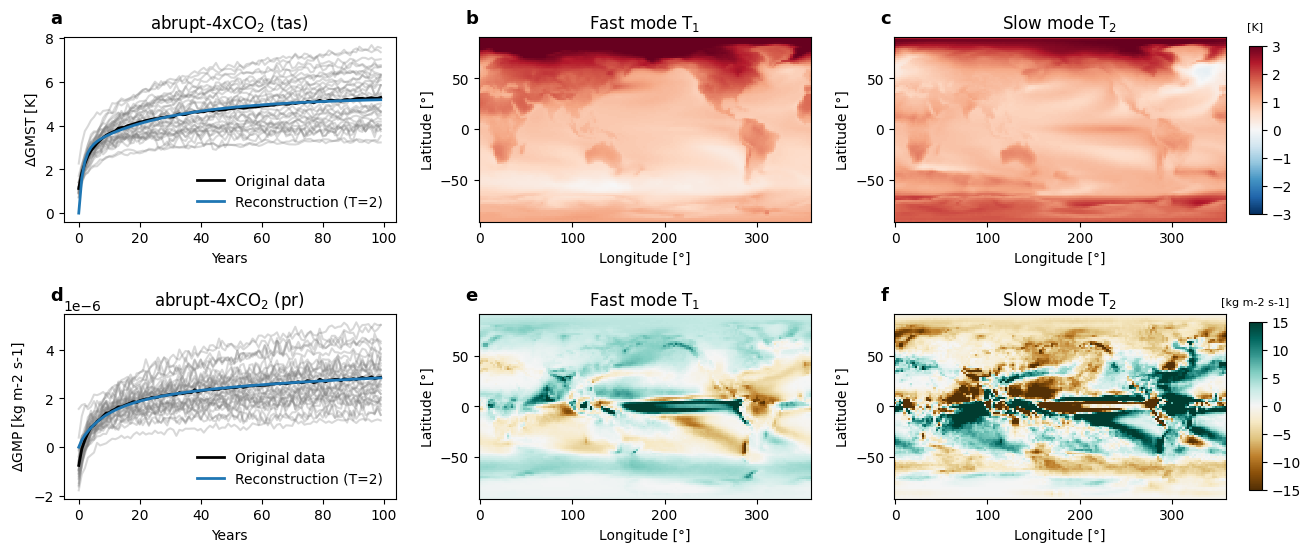

In [22]:
vmins = [-3,-15]
vmaxs = [3,15]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
labels = (["a","b","c"],
          ["d","e","f"])
cmaps = ["RdBu_r","BrBG"]

fig = plt.figure(figsize=(15,6))
gs = GridSpec(2, 3, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_title("abrupt-4xCO$_2$ ("+var+")")
    sub.set_xlabel("Years")
    sub.set_ylabel(titles[nv])
    #sub.set_xlim(0,100)
    #sub.set_ylim(0,8)
    for nm,mname in enumerate(models):
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", alpha=0.3)
        #sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="gray", alpha=0.3)
    sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[nv,:,:],0), color="black", lw=2, label="Original data")
    sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[nv,:,:],0), color="tab:blue", lw=2, label="Reconstruction (T=2)")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1])#, projection=ccrs.PlateCarree()) 
    #sub.coastlines(lw=0.5)
    sub.set_title("Fast mode T$_1$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_data_T1[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][1], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 2])#, projection=ccrs.PlateCarree())
    #sub.coastlines(lw=0.5)
    sub.set_title("Slow mode T$_2$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_data_T2[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][2], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    # external colorbar
    if var == "tas":
        cbar = fig.add_axes([0.915, 0.585, 0.009, 0.28])
    if var == "pr":
        cbar = fig.add_axes([0.915, 0.125, 0.009, 0.28])
    fig.colorbar(cont, cax=cbar,orientation='vertical')
    cbar.set_title(units[nv], size=8, pad=12, ha="center")

fig.subplots_adjust(wspace=0.25, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')

# Aerosol patterns

In [20]:
mname

'CanESM5'

In [21]:
training_data_dict[mname]

{'base': <xarray.Dataset> Size: 131MB
 Dimensions:  (ens: 1, lat: 64, lon: 128, year: 1000)
 Coordinates:
   * ens      (ens) int64 8B 1
     height   float64 8B ...
   * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
   * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
   * year     (year) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
 Data variables:
     tas      (ens, year, lat, lon) float64 66MB ...
     pr       (ens, year, lat, lon) float64 66MB ...,
 'co2x4': <xarray.Dataset> Size: 20MB
 Dimensions:  (ens: 1, lat: 64, lon: 128, year: 151)
 Coordinates:
   * ens      (ens) int64 8B 1
     height   float64 8B ...
   * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
   * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
   * year     (year) int64 1kB 0 1 2 3 4 5 6 7 ... 144 145 146 147 148 149 150
 Data variables:
     tas      (ens, year, lat, lon) float64 

In [22]:
%%capture
#if 'ACCESS-ESM1-5' in models: models.pop(models.index('ACCESS-ESM1-5'))
#if 'AWI-CM-1-1-MR' in models: models.pop(models.index('AWI-CM-1-1-MR'))
#if 'BCC-CSM2-MR' in models: models.pop(models.index('BCC-CSM2-MR'))


CMIP_aer_pattern_dict = {}
for nm,mname in enumerate(models):

    # select model-specific training data
    training_data = training_data_dict[mname]

    # create GHG modes and spatial pattern
    CMIP_aer_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data[key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )